In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import os

In [44]:
VOCAB_SIZE = 12000
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]
CONTEXT_LENGTH = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
D_MODEL = 256
NUM_HEADS = 4
NUM_LAYERS = 4
FFN_DIM = 1024
DROPOUT = 0.1
NUM_EPOCHS = 5
CHECKPOINT_PATH = "/kaggle/working/checkpoints/transformer_checkpoint.pt"

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [13]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [14]:
for i in range(10):
    print(dataset["train"][i]["text"])


 = Valkyria Chronicles III = 


 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 

 The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series 

In [15]:
def clean_text(text):
    text = text.lower() # converts everything to lowercase
    text = re.sub(r"\s+", " ", text) # replaces multiple whitespaces with only one space
    text = text.replace("@-@", "-") # remove heading markers
    text = text.strip() # removes trailing whitespace
    return text

In [16]:
train_texts = []
val_texts = []
test_texts = []

for example in dataset["train"]:
    text = clean_text(example["text"])
    if text:
        train_texts.append(text)

for example in dataset["test"]:
    text = clean_text(example["text"])
    if text:
        test_texts.append(text)

for example in dataset["validation"]:
    text = clean_text(example["text"])
    if text:
        val_texts.append(text)

print("Number of training texts:", len(train_texts))
print(train_texts[:5])

Number of training texts: 23767
['= valkyria chronicles iii =', 'senjō no valkyria 3 : unrecorded chronicles ( japanese : 戦場のヴァルキュリア3 , lit . valkyria of the battlefield 3 ) , commonly referred to as valkyria chronicles iii outside japan , is a tactical role - playing video game developed by sega and media.vision for the playstation portable . released in january 2011 in japan , it is the third game in the valkyria series . employing the same fusion of tactical and real - time gameplay as its predecessors , the story runs parallel to the first game and follows the " nameless " , a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit " calamaty raven " .', "the game began development in 2010 , carrying over a large portion of the work done on valkyria chronicles ii . while it retained the standard features of the series , it also underwent multiple adjustments , such as making the game

In [17]:
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text)

In [18]:
sample = "the game is role-playing."
tokens = tokenize(sample)
print(tokens)

['the', 'game', 'is', 'role', '-', 'playing', '.']


In [19]:
train_tokens = []
val_tokens = []
test_tokens = []

for text in train_texts:
    train_tokens.extend(tokenize(text))

for text in val_texts:
    val_tokens.extend(tokenize(text))

for text in test_texts:
    test_tokens.extend(tokenize(text))
    
print("Number of tokens:", len(train_tokens))
print(train_tokens[:50])

Number of tokens: 2088325
['=', 'valkyria', 'chronicles', 'iii', '=', 'senjō', 'no', 'valkyria', '3', ':', 'unrecorded', 'chronicles', '(', 'japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'valkyria', 'of', 'the', 'battlefield', '3', ')', ',', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', ',', 'is', 'a', 'tactical', 'role', '-', 'playing', 'video', 'game', 'developed', 'by', 'sega', 'and', 'media', '.']


In [20]:
token_counts = Counter(train_tokens)
print(token_counts.most_common(20))

[('the', 130771), (',', 102624), ('.', 84291), ('of', 57032), ('and', 50738), ('in', 45019), ('to', 39522), ('a', 36567), ('=', 29570), ('"', 28309), ('was', 21008), ("'", 18655), ('-', 17337), ('on', 15141), ('as', 15058), ('s', 14982), ('that', 14351), ('for', 13795), ('with', 13012), ('by', 12718)]


In [21]:
num_regular_tokens = VOCAB_SIZE - len(SPECIAL_TOKENS)

most_common_tokens = [
    token
    for token, count in token_counts.most_common(num_regular_tokens)
]
print(len(most_common_tokens))
print(most_common_tokens[:20])

11996
['the', ',', '.', 'of', 'and', 'in', 'to', 'a', '=', '"', 'was', "'", '-', 'on', 'as', 's', 'that', 'for', 'with', 'by']


In [22]:
stoi = {} # string to int

for idx, token in enumerate(SPECIAL_TOKENS): # ID special tokens
    stoi[token] = idx
    
for idx, token in enumerate( # ID rest of vocab
    most_common_tokens,
    start=len(SPECIAL_TOKENS)
):
    stoi[token] = idx
    
print(len(stoi))
print(list(stoi.items())[:20])

12000
[('<PAD>', 0), ('<UNK>', 1), ('<BOS>', 2), ('<EOS>', 3), ('the', 4), (',', 5), ('.', 6), ('of', 7), ('and', 8), ('in', 9), ('to', 10), ('a', 11), ('=', 12), ('"', 13), ('was', 14), ("'", 15), ('-', 16), ('on', 17), ('as', 18), ('s', 19)]


In [23]:
itos = {idx: token for token, idx in stoi.items()} # int to string
print(list(itos.items())[:6])

[(0, '<PAD>'), (1, '<UNK>'), (2, '<BOS>'), (3, '<EOS>'), (4, 'the'), (5, ',')]


In [24]:
def encode(text):
    tokens = tokenize(text)
    
    token_ids = []
    
    for token in tokens:
        if token in stoi:
            token_ids.append(stoi[token])
        else:
            token_ids.append(stoi["<UNK>"])
    
    return token_ids

In [85]:
def decode(token_ids):
    tokens = []

    for token_id in token_ids:
        tokens.append(itos[token_id])

    return " ".join(tokens)

In [26]:
sample = "The game is role-playing." # testing encode and decode

tokens = tokenize(sample.lower())
encoded = encode(sample.lower())
decoded = decode(encoded)

print("Original:")
print(sample)

print("\nTokens:")
print(tokens)

print("\nEncoded:")
print(encoded)

print("\nDecoded:")
print(decoded)

print("\nVocabulary size:", len(stoi))
print("\nNumber of tokens:", len(train_tokens))

Original:
The game is role-playing.

Tokens:
['the', 'game', 'is', 'role', '-', 'playing', '.']

Encoded:
[4, 73, 27, 305, 16, 580, 6]

Decoded:
the game is role - playing .

Vocabulary size: 12000

Number of tokens: 2088325


In [27]:
def tokens_to_ids(tokens):
    return [
        stoi[token] if token in stoi else stoi["<UNK>"]
        for token in tokens
    ]
    
train_ids = tokens_to_ids(train_tokens)
val_ids = tokens_to_ids(val_tokens)
test_ids = tokens_to_ids(test_tokens)

In [28]:
def create_sequences(token_ids, context_length):
    inputs = []
    targets = []

    for i in range(len(token_ids) - context_length):
        input_sequence = token_ids[i : i + context_length]
        target_sequence = token_ids[i + 1 : i + context_length + 1]

        inputs.append(input_sequence)
        targets.append(target_sequence)

    return inputs, targets

In [29]:
class LanguageModelDataset(Dataset):
    def __init__(self, token_ids, context_length):
        self.token_ids = torch.tensor(token_ids, dtype=torch.long)
        self.context_length = context_length

    def __len__(self):
        return len(self.token_ids) - self.context_length

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.context_length]
        y = self.token_ids[idx + 1 : idx + self.context_length + 1]
        return x, y

In [30]:
train_dataset = LanguageModelDataset(train_ids, CONTEXT_LENGTH)
val_dataset = LanguageModelDataset(val_ids, CONTEXT_LENGTH)
test_dataset = LanguageModelDataset(test_ids, CONTEXT_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [31]:
class TokenPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, context_length, d_model):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(context_length, d_model)

    def forward(self, x):
        batch_size, sequence_length = x.shape

        positions = torch.arange(
            sequence_length,
            device=x.device
        )

        token_embeddings = self.token_embedding(x)
        position_embeddings = self.position_embedding(positions)

        return token_embeddings + position_embeddings

In [32]:
embedding = TokenPositionalEmbedding(
    VOCAB_SIZE,
    CONTEXT_LENGTH,
    D_MODEL
).to(device)

x, y = next(iter(train_loader))
x = x.to(device)

embedded = embedding(x)

print("Input shape:", x.shape)
print("Embedding shape:", embedded.shape)

Input shape: torch.Size([32, 64])
Embedding shape: torch.Size([32, 64, 256])


In [55]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=DROPOUT):
        super().__init__()

        assert d_model % num_heads == 0
        
        self.last_attention_weights = None

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, sequence_length, d_model = x.shape

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        Q = Q.view(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        K = K.view(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        V = V.view(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)
        scores = scores / (self.head_dim ** 0.5)

        mask = torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                device=x.device
            ),
            diagonal=1
        ).bool()

        scores = scores.masked_fill(mask, float("-inf"))

        attention_weights = F.softmax(scores, dim=-1)
        self.last_attention_weights = attention_weights.detach()
        attention_weights = self.dropout(attention_weights)

        output = attention_weights @ V

        output = output.transpose(1, 2).contiguous()

        output = output.view(
            batch_size,
            sequence_length,
            d_model
        )

        output = self.out_proj(output)

        return output

In [34]:
attention = MultiHeadSelfAttention(
    D_MODEL,
    NUM_HEADS,
    DROPOUT
).to(device)

output = attention(embedded)

print("Input shape:", embedded.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([32, 64, 256])
Output shape: torch.Size([32, 64, 256])


In [35]:
class FeedForward(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout=DROPOUT):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)

In [36]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, ffn_dim, dropout=DROPOUT):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attention = MultiHeadSelfAttention(
            d_model,
            num_heads,
            dropout
        )

        self.norm2 = nn.LayerNorm(d_model)
        self.feed_forward = FeedForward(
            d_model,
            ffn_dim,
            dropout
        )

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.feed_forward(self.norm2(x))

        return x

In [37]:
block = TransformerBlock(
    D_MODEL,
    NUM_HEADS,
    FFN_DIM,
    DROPOUT
).to(device)

output = block(embedded)

print("Output shape:", output.shape)

Output shape: torch.Size([32, 64, 256])


In [38]:
class GPTModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        context_length,
        d_model,
        num_heads,
        num_layers,
        ffn_dim,
        dropout=DROPOUT
    ):
        super().__init__()

        self.embedding = TokenPositionalEmbedding(
            vocab_size,
            context_length,
            d_model
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model,
                num_heads,
                ffn_dim,
                dropout
            )
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)

        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, x):
        x = self.embedding(x)

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)

        logits = self.output_layer(x)

        return logits

In [39]:
model = GPTModel(
    vocab_size=VOCAB_SIZE,
    context_length=CONTEXT_LENGTH,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT
).to(device)

In [40]:
x, y = next(iter(train_loader))

x = x.to(device)
y = y.to(device)

logits = model(x)

print("Input shape:", x.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([32, 64])
Logits shape: torch.Size([32, 64, 12000])


In [41]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Total parameters: {total_params:,}")

Total parameters: 9,331,936


In [42]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [45]:
train_losses = []
val_losses = []

start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    start_epoch = checkpoint["epoch"] + 1

    print(f"Resuming from epoch {start_epoch + 1}")

else:
    os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
    
for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()
    total_train_loss = 0

    for batch_idx, (x, y) in enumerate(train_loader):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits.view(-1, VOCAB_SIZE),
            y.view(-1)
        )

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        if (batch_idx + 1) % 20000 == 0:
            print(
                f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
                f"Batch {batch_idx + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(
                logits.view(-1, VOCAB_SIZE),
                y.view(-1)
            )

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
    }, CHECKPOINT_PATH)

    print(f"Checkpoint saved after epoch {epoch + 1}")

Epoch 1/5 | Batch 20000/65259 | Loss: 3.5369
Epoch 1/5 | Batch 40000/65259 | Loss: 3.0157
Epoch 1/5 | Batch 60000/65259 | Loss: 2.9270
Epoch 1/5 | Train Loss: 3.3382 | Val Loss: 5.2558
Checkpoint saved after epoch 1
Epoch 2/5 | Batch 20000/65259 | Loss: 2.6762
Epoch 2/5 | Batch 40000/65259 | Loss: 2.4259
Epoch 2/5 | Batch 60000/65259 | Loss: 2.4354
Epoch 2/5 | Train Loss: 2.5711 | Val Loss: 5.6935
Checkpoint saved after epoch 2
Epoch 3/5 | Batch 20000/65259 | Loss: 2.3873
Epoch 3/5 | Batch 40000/65259 | Loss: 2.4035
Epoch 3/5 | Batch 60000/65259 | Loss: 2.2920
Epoch 3/5 | Train Loss: 2.2972 | Val Loss: 5.9908
Checkpoint saved after epoch 3
Epoch 4/5 | Batch 20000/65259 | Loss: 2.1752
Epoch 4/5 | Batch 40000/65259 | Loss: 2.0924
Epoch 4/5 | Batch 60000/65259 | Loss: 1.9485
Epoch 4/5 | Train Loss: 2.1212 | Val Loss: 6.2390
Checkpoint saved after epoch 4
Epoch 5/5 | Batch 20000/65259 | Loss: 2.1203
Epoch 5/5 | Batch 40000/65259 | Loss: 2.1258
Epoch 5/5 | Batch 60000/65259 | Loss: 1.9591
E

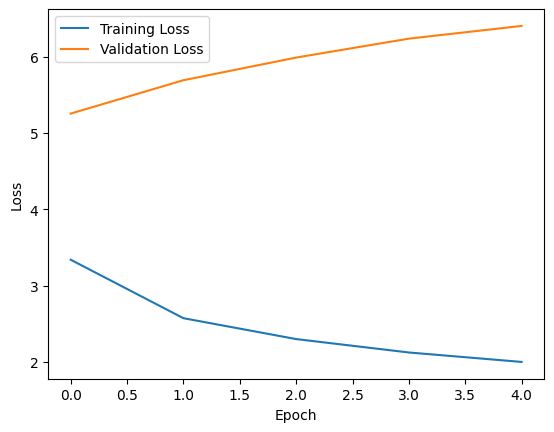

In [46]:
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [47]:
val_loss = val_losses[-1]

perplexity = np.exp(val_loss)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Perplexity: {perplexity:.2f}")

Validation Loss: 6.4060
Validation Perplexity: 605.46


In [67]:
for block in model.blocks:
    block.attention.last_attention_weights = None

In [68]:
def attention_forward(self, x):
    batch_size, sequence_length, d_model = x.shape

    Q = self.q_proj(x)
    K = self.k_proj(x)
    V = self.v_proj(x)

    Q = Q.view(
        batch_size,
        sequence_length,
        self.num_heads,
        self.head_dim
    ).transpose(1, 2)

    K = K.view(
        batch_size,
        sequence_length,
        self.num_heads,
        self.head_dim
    ).transpose(1, 2)

    V = V.view(
        batch_size,
        sequence_length,
        self.num_heads,
        self.head_dim
    ).transpose(1, 2)

    scores = Q @ K.transpose(-2, -1)
    scores = scores / (self.head_dim ** 0.5)

    mask = torch.triu(
        torch.ones(
            sequence_length,
            sequence_length,
            device=x.device
        ),
        diagonal=1
    ).bool()

    scores = scores.masked_fill(mask, float("-inf"))

    attention_weights = F.softmax(scores, dim=-1)

    self.last_attention_weights = attention_weights.detach()

    attention_weights = self.dropout(attention_weights)

    output = attention_weights @ V

    output = output.transpose(1, 2).contiguous()

    output = output.view(
        batch_size,
        sequence_length,
        d_model
    )

    output = self.out_proj(output)

    return output

In [70]:
import types

for block in model.blocks:
    block.attention.forward = types.MethodType(
        attention_forward,
        block.attention
    )

In [71]:
prompt = input("Enter a prompt: ")

tokens = tokenize(prompt)
token_ids = encode(prompt)

input_ids = torch.tensor(
    token_ids,
    dtype=torch.long,
    device=device
).unsqueeze(0)

model.eval()

with torch.no_grad():
    logits = model(input_ids)

attention = model.blocks[0].attention.last_attention_weights[0, 0]

attention = attention.cpu().numpy()

print("Tokens:", tokens)
print("Attention shape:", attention.shape)

Enter a prompt:  a blue


Tokens: ['a', 'blue']
Attention shape: (2, 2)


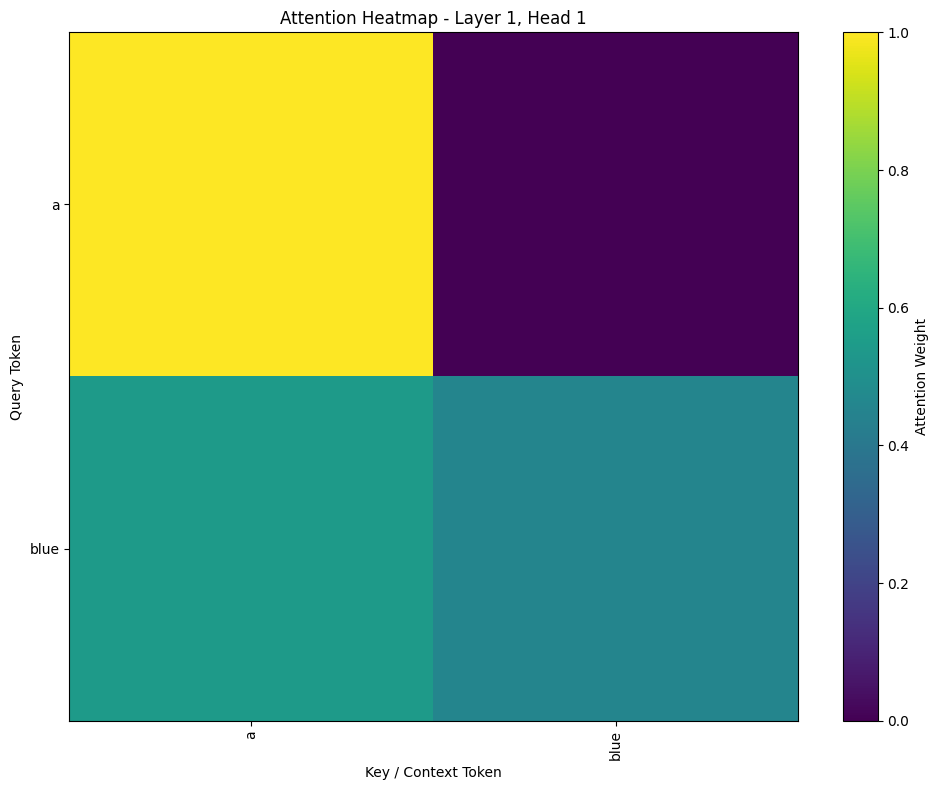

In [72]:
plt.figure(figsize=(10, 8))

plt.imshow(
    attention,
    aspect="auto"
)

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=90
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key / Context Token")
plt.ylabel("Query Token")
plt.title("Attention Heatmap - Layer 1, Head 1")

plt.colorbar(
    label="Attention Weight"
)

plt.tight_layout()
plt.show()

In [79]:
def generate_text(
    model,
    prompt,
    max_new_tokens=50,
    temperature=1.0,
    top_k=50
):
    model.eval()

    token_ids = encode(prompt)

    input_ids = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    for _ in range(max_new_tokens):

        input_ids = input_ids[:, -CONTEXT_LENGTH:]

        with torch.no_grad():
            logits = model(input_ids)

        next_token_logits = logits[:, -1, :]

        # Temperature scaling
        next_token_logits = next_token_logits / temperature

        # Top-K sampling
        if top_k is not None:
            top_k_logits, top_k_indices = torch.topk(
                next_token_logits,
                top_k,
                dim=-1
            )

            probabilities = F.softmax(
                top_k_logits,
                dim=-1
            )

            sampled_index = torch.multinomial(
                probabilities,
                num_samples=1
            )

            next_token = top_k_indices.gather(
                -1,
                sampled_index
            )

        else:
            probabilities = F.softmax(
                next_token_logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            )

        input_ids = torch.cat(
            [input_ids, next_token],
            dim=1
        )

    generated_ids = input_ids[0].tolist()

    return decode(generated_ids)

In [84]:
prompt = input("Enter a prompt: ")

num_tokens = int(
    input("How many tokens should be generated? ")
)

temperature = float(
    input("Enter temperature (e.g. 0.7, 1.0, 1.2): ")
)

result = generate_text(
    model,
    prompt,
    max_new_tokens=num_tokens,
    temperature=temperature
)

print("\nGenerated text:")
print(result)

attention_weights = model.blocks[0].attention.last_attention_weights
print(attention_weights.shape)

Enter a prompt:  the queen
How many tokens should be generated?  50
Enter temperature (e.g. 0.7, 1.0, 1.2):  0.8



Generated text:
the queen ' s gate tunnel, and the subsequent enemies of the future queen elizabeth ii in 1989. the remainder of the commission ' s first gorilla later, in 1991. = = development of the law = = the church ' s earliest settlers was to be completed
torch.Size([1, 4, 51, 51])


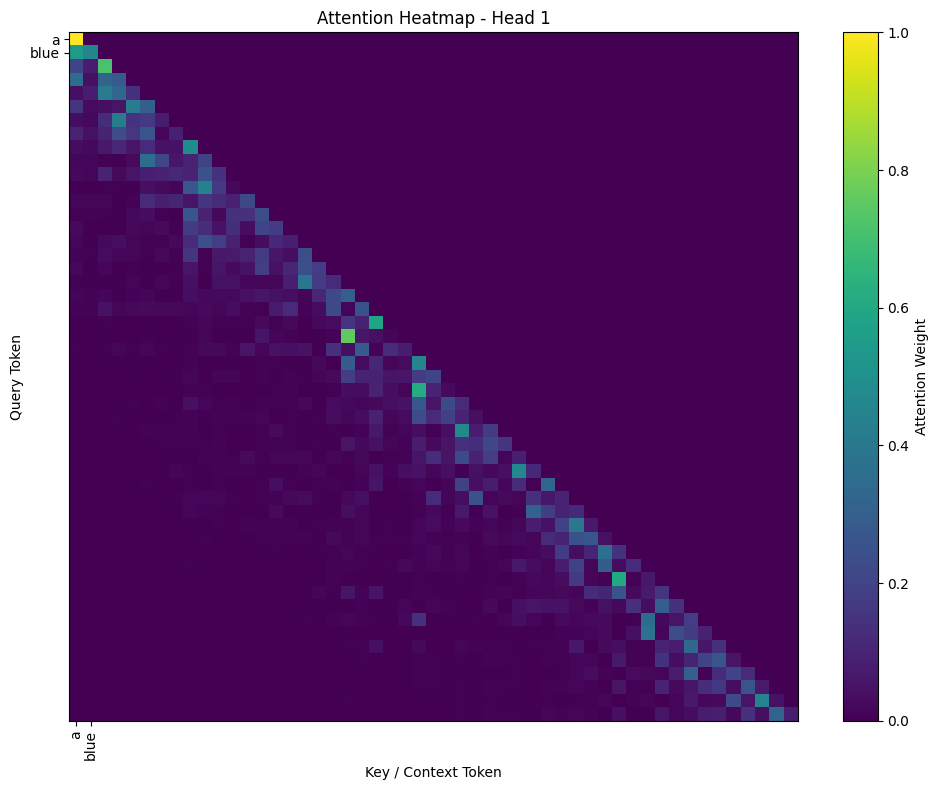

In [81]:
tokens = tokenize(prompt)

attention = attention_weights[0, 0].cpu().numpy()

plt.figure(figsize=(10, 8))

plt.imshow(attention, aspect="auto")

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=90
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key / Context Token")
plt.ylabel("Query Token")
plt.title("Attention Heatmap - Head 1")

plt.colorbar(label="Attention Weight")

plt.tight_layout()
plt.show()